# **NOTEBOOK 1 : plots de base de QZabre**

## Convertir toutes les données .h5 en .txt

La fonction ``convert_all_odmr_and_scalar`` change toutes les données ``odmr.h5`` et ``scalarData.h5`` (qui se trouvent dans les fichiers de données de QZabre après une mesure).  
Il faut bien spécifier le chemin du dossier contenant tous les fichiers de mesures.  
Il faut bien définir le directoir de travail où se trouve les helpers.py et autre fichiers de code .py contenant les fonctions.  
Les fichiers textes sont ajoutés dans chacun des dossiers de mesure.


In [1]:
from pathlib import Path

#***** MODIFIER ICI LES DIRECTORY *****
data_directory = Path(r"C:\Users\herma\OneDrive\Bureau\Etudes EPFL\PDM\Datas2")
working_directory = Path(r"C:\Users\herma\OneDrive\Bureau\Etudes EPFL\PDM")
#**************************************

from helpers import convert_all_odmr_and_scalar
convert_all_odmr_and_scalar(data_directory, show_skip=False, date_min="2025-07-01")       #ici, date_min ne converti pas les fichiers anterieurs au 01/07/2026, on peut mettre None sinon

Parcours de C:\Users\herma\OneDrive\Bureau\Etudes EPFL\PDM\Datas2 ...


Terminé (fichiers .h5 convertis en .txt)


## Creation de la liste des dates de mesures

Construction automatique d'une liste de dates à partir des noms des fichiers de données.  
On peut manuellement ajouter des dates à supprimer de la liste (mesures ratées, etc).  

In [2]:
from helpers import build_date_list

#Fonction qui construit automatiquement une liste de toutes les dates dans le fichier de données
all_dates = build_date_list(data_directory)

dates_à_supprimer = {
    "2025-11-17-18-36-10", #mesure bande verticale
    "2025-11-18-02-03-46", #scan raté, seulement quelques lignes
    "2025-12-03-16-41-04", #celle rotation 90 trop chiant à changer

    #tous les autres scans raté (quelques lignes, où bien scans vraiment illisibles / incohérents):
    "2025-11-04-19-11-27", "2025-11-06-18-19-44", "2025-11-07-18-38-38", "2025-11-08-08-46-50", "2025-11-08-18-50-31", "2025-11-09-15-32-27", "2025-11-09-23-24-49", "2025-11-10-09-51-47",
    "2025-11-10-12-15-04", "2025-11-11-18-31-55", "2025-11-12-21-34-31", "2025-11-20-17-01-40","2025-12-12-11-52-52", "2025-12-15-01-22-30"
}

all_dates = [d for d in all_dates if d not in dates_à_supprimer]

print("[indices] Dates :")
for i, d in enumerate(all_dates):
    print(f"[{i}] {d}")

[indices] Dates :
[0] 2025-06-20-18-43-28
[1] 2025-07-20-16-46-16
[2] 2025-10-28-08-31-40
[3] 2025-10-28-14-57-09
[4] 2025-10-30-12-57-30
[5] 2025-10-31-08-28-12
[6] 2025-10-31-11-48-09
[7] 2025-10-31-18-26-22
[8] 2025-11-01-19-06-18
[9] 2025-11-02-09-26-37
[10] 2025-11-11-08-25-09
[11] 2025-11-12-13-06-46
[12] 2025-11-13-13-50-33
[13] 2025-11-13-22-20-57
[14] 2025-11-14-22-59-02
[15] 2025-11-15-20-13-45
[16] 2025-11-16-23-41-29
[17] 2025-11-18-12-47-24
[18] 2025-11-19-15-47-12
[19] 2025-11-21-17-50-24
[20] 2025-11-22-00-14-27
[21] 2025-11-22-09-40-00
[22] 2025-11-23-00-27-18
[23] 2025-11-23-18-37-53
[24] 2025-11-24-13-06-13
[25] 2025-11-25-00-58-29
[26] 2025-11-25-19-49-32
[27] 2025-11-26-14-16-10
[28] 2025-11-27-14-12-52
[29] 2025-11-28-12-45-13
[30] 2025-11-29-16-05-00
[31] 2025-11-30-04-07-17
[32] 2025-11-30-13-12-29
[33] 2025-11-30-21-38-20
[34] 2025-12-01-13-42-23
[35] 2025-12-01-22-11-42
[36] 2025-12-02-13-07-59
[37] 2025-12-03-02-08-52
[38] 2025-12-04-13-29-57
[39] 2025-12-05-1

On peut ensuite choisir en détail quelles dates l'on veut séléctionner. Ici on ne sélectionne que les 10 premières dates.

In [3]:
#Pour débug les foncdions des helpers sans avoir à restart le kernel et reload les fonction à chaque modification
%load_ext autoreload
%autoreload 2

date = "2025-07-20-16-46-16"
dates = all_dates[:10]              #[-13:] #[-9:-5]


Léger pré traitement des données (fenêtre de lissage, normalisation par la médiane), et désactivation éventuelle des fréquences (utiles pour débugger les fits, mais à laisser en "frequences_odmr" maintenant).  

In [4]:
# Pré-traitement (normalisation et lissage)
NORMALIZE  = True     # True => normalise counts par la médiane du sweep
SMOOTH_WIN = 3        # fenêtre de lissage (entier impair >= 3) ; 0 pour désactiver

# Performance
DOWNCAST_INT = True   # essaie de convertir counts en int32 pour économiser de la mémoire

## Chargement des données

Se fait via:
- ``load_df1`` pour le ``odmr.txt`` (dataset 1 contenant les spectres odmr complet, sur toute la surface 2D).  
- ``load_df2`` pour le ``scalarData.txt`` (dataset 2 contenant TOUS les scans 2D que l'on voit sur l'écran QZabre (afm:height, afm:phase, etc)).  

La fonction ``concatenate_data_df1`` permet de concatener des datasets. Par exemple, deux mesures 2D que l'on souhaite coller en une seule grande mesure.  
(la fonction est assez embêtante à utiliser, à cause de divers problèmes d'indices mal optimisés dans les set de données de QZabre, il est préférable de ne pas essayer de concaténer différentes mesures, même si ça reste possible)

Note : les deux datasets n'ont pas les mêmes indices (i,j), les fonctions de plots prennent ça en compte et mettent tout dans la même convention.

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#print("pandas:", pd.__version__)

In [6]:
# CHARGEMENT DES DATA_1 --> SPECTROGRAMMES

os.chdir(working_directory)
from helpers import load_df1, concatener_data_df1

base = data_directory / f"{date}-odmr_hardware" / "seq0" / "eval"
os.chdir(base)
TXT_PATH = "odmr.txt"  # "integratedCounts.txt"
    
df = load_df1(TXT_PATH, DOWNCAST_INT, infos=True)

# example de concatenation de données
if date == "2025-11-16-23-41-29":
    band_folder = data_directory / "2025-11-17-18-36-10-odmr_hardware" / "seq0" / "eval"
    band_file = band_folder / "odmr.txt"
    df_band = load_df1(band_file, DOWNCAST_INT=True)
    df = concatener_data_df1(df, df_band, infos=False)

df.head()


Dimensions: i=110, j=110, k=100
Index(['i', 'j', 'k', 'frequency', 'sig', 'contrast'], dtype='object')


,i,j,k,frequency,sig,contrast
0,0,0,0,2.699575e+09,12272,0.987319
1,0,0,1,2.701575e+09,12159,0.978228
2,0,0,2,2.703575e+09,12052,0.969620
3,0,0,3,2.705575e+09,12198,0.981366
4,0,0,4,2.707575e+09,12244,0.985067


Ici, ``sig`` fait référence au counts bruts du signal

In [7]:
# CHARGEMENT DES DATA_2 --> MESURES QZABRE (afm:height, afm:phase, odmr:mTesla0, etc)

os.chdir(working_directory)
from helpers import load_df2, concatener_data_df2

base = Path(r"C:\Users\herma\OneDrive\Bureau\Etudes EPFL\PDM\Datas2") / f"{date}-odmr_hardware"
os.chdir(base)
SCALAR_PATH = "scalarData.txt"

df2 = load_df2(SCALAR_PATH, infos=True)

if date == "2025-11-16-23-41-29":
    band_folder = data_directory / "2025-11-17-18-36-10-odmr_hardware"
    band_file = band_folder / "scalarData.txt"
    df_band = load_df2(band_file)
    df2 = concatener_data_df2(df2, df_band, infos=False)

#print(df2["afm:height"].keys())
df2.head()

Dimensions: i=110, j=110
Index(['i', 'j', 'odmr:mTesla0', 'odmr:Gauss0', 'odmr:resonanceFrequency0',
       'odmr:resonanceFrequency_err0', 'odmr:FWHM0', 'odmr:FWHM_err0',
       'odmr:contrast0', 'odmr:contrast_err0', 'odmr:sensitivity0',
       'odmr:integrationTime', 'odmr:intensity', 'afm:height', 'afm:amplitude',
       'afm:phase', 'afm:frequency', 'afm:scanHeight', 'afm:refPointX',
       'afm:refPointY', 'afm:refPointZ', 'afm:zDist', 'afm:success',
       'moke:difference', 'moke:A', 'moke:B', 'moke:arctan((A-diff)/A)',
       'moke:difference/(A+B)'],
      dtype='object')


,i,j,odmr:mTesla0,odmr:Gauss0,odmr:resonanceFrequency0,odmr:resonanceFrequency_err0,odmr:FWHM0,odmr:FWHM_err0,odmr:contrast0,odmr:contrast_err0,...,afm:refPointX,afm:refPointY,afm:refPointZ,afm:zDist,afm:success,moke:difference,moke:A,moke:B,moke:arctan((A-diff)/A),moke:difference/(A+B)
0,0,0,2.479083,24.790827,2.800524e+09,1.002687e+06,3.483033e+07,2.787853e+06,0.128619,0.005013,...,NaN,NaN,NaN,1.500000e-07,1.0,0.0,0.0,0.0,0.0,0.0
1,0,1,5.745540,57.455398,2.708982e+09,1.655074e+06,5.905917e+07,4.870061e+06,0.065167,0.003678,...,NaN,NaN,NaN,1.500000e-07,1.0,0.0,0.0,0.0,0.0,0.0
2,0,2,5.793906,57.939062,2.707626e+09,1.531914e+06,5.895501e+07,4.505199e+06,0.071523,0.003743,...,NaN,NaN,NaN,1.500000e-07,1.0,0.0,0.0,0.0,0.0,0.0
3,0,3,6.580376,65.803760,2.685585e+09,1.319314e+06,6.121423e+07,3.901606e+06,0.077757,0.003377,...,NaN,NaN,NaN,1.500000e-07,1.0,0.0,0.0,0.0,0.0,0.0
4,0,4,6.729541,67.295410,2.681405e+09,8.425056e+05,4.557827e+07,2.430291e+06,0.090797,0.003370,...,NaN,NaN,NaN,1.500000e-07,1.0,0.0,0.0,0.0,0.0,0.0


## PLOT des données de QZabre

Données brutes, les plots ne sont pas basés sur les "double fits" lorenziens.  
La fonction ``overlay_max_band`` permet d'ajouter par dessus les plots le maximum de contrast (par exemple le percentile haut de contrast de 25% : top_pct=25)

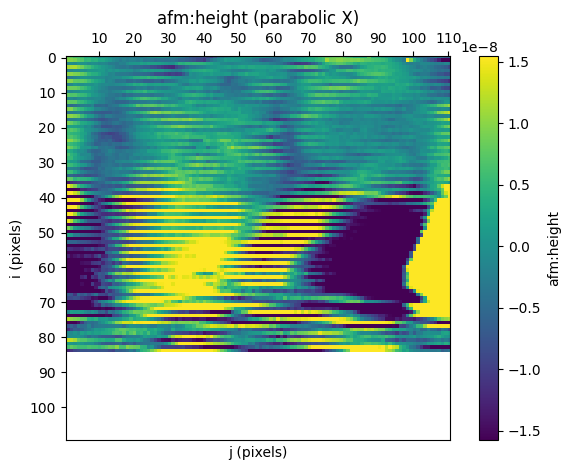

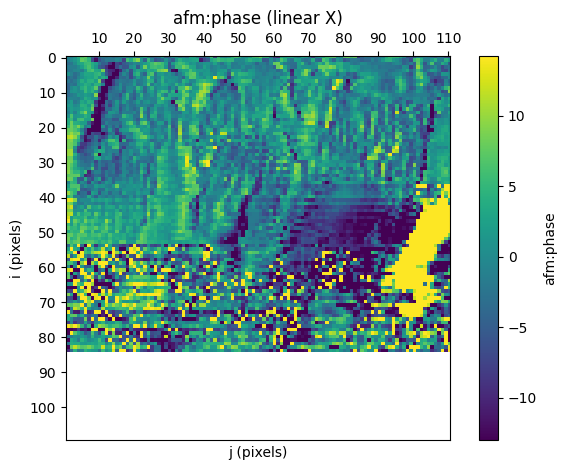

In [8]:
os.chdir(working_directory)
from helpers import plot_QZabre, plot_on_ax, overlay_max_band

# PREPROCESS :  (les mêmes preprocess que sur l'interface QZabre, avec "mean plane substract" etc)     
#       - None / "none"
#       - "mean plane subtract" / "mean_plane"
#       - "parabolic background subtract" / "parabolic"
#       - "linear X"
#       - "linear Y"
#       - "parabolic X"
#       - "parabolic Y"
plot_QZabre(df2, "afm:height", robust_pct=11.5, preprocess="parabolic X")
plot_QZabre(df2, "afm:phase", robust_pct=6.5, preprocess="linear X")

#plot_QZabre(df2, "afm:phase")                 
#plot_QZabre(df2, "odmr:mTesla0", robust_pct=0.5, vmax=15)   
#plot_QZabre(df2, "afm:phase", robust_pct=5.5)   

Boucle automatique qui couvre toutes les données dans ``dates`` défini plus haut.  
4 figures par mesures (ici : odmr:mTesla0, afm:phase, odmr:contrast0, afm:height).  
Il est possible de changer et de mettre n'importe quel autre nom de "key" du dataset 2 (voir la liste dans le tableau df2.head() plus haut)

DATE: 2025-06-20-18-43-28


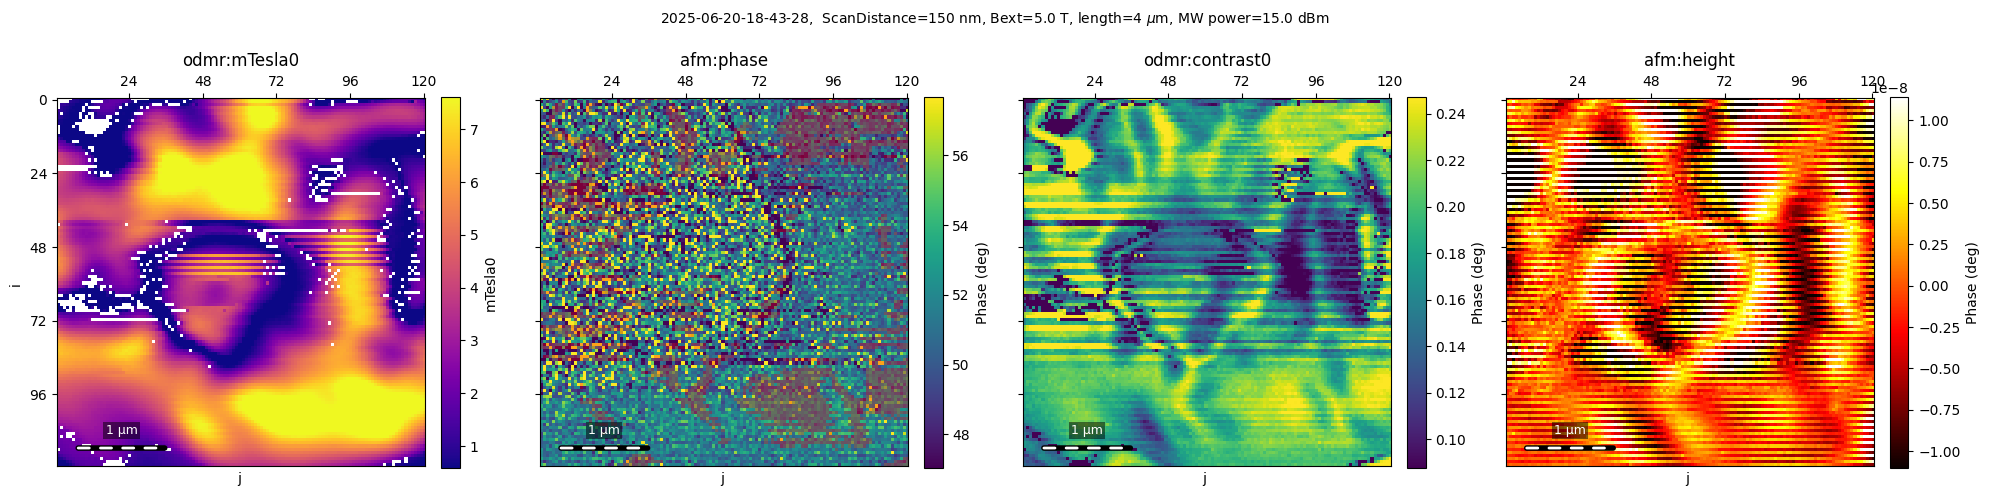

DATE: 2025-07-20-16-46-16


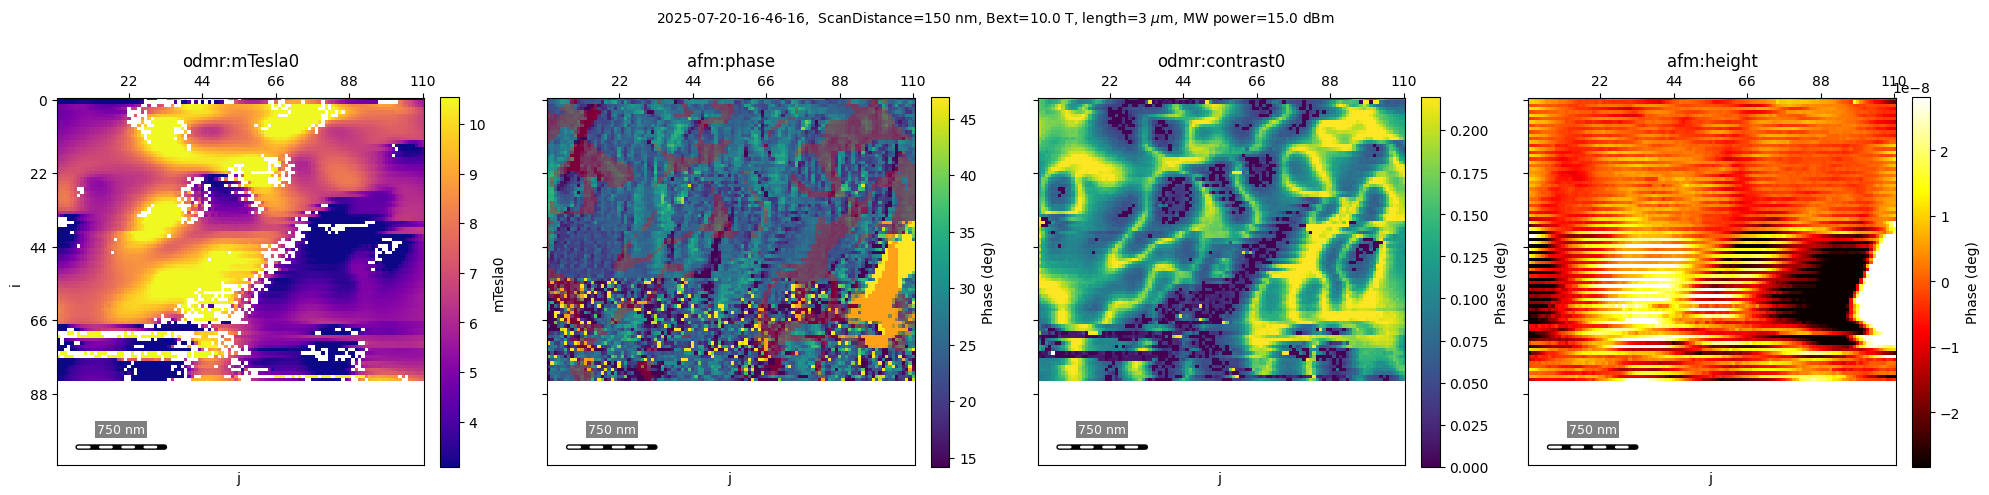

DATE: 2025-10-28-08-31-40


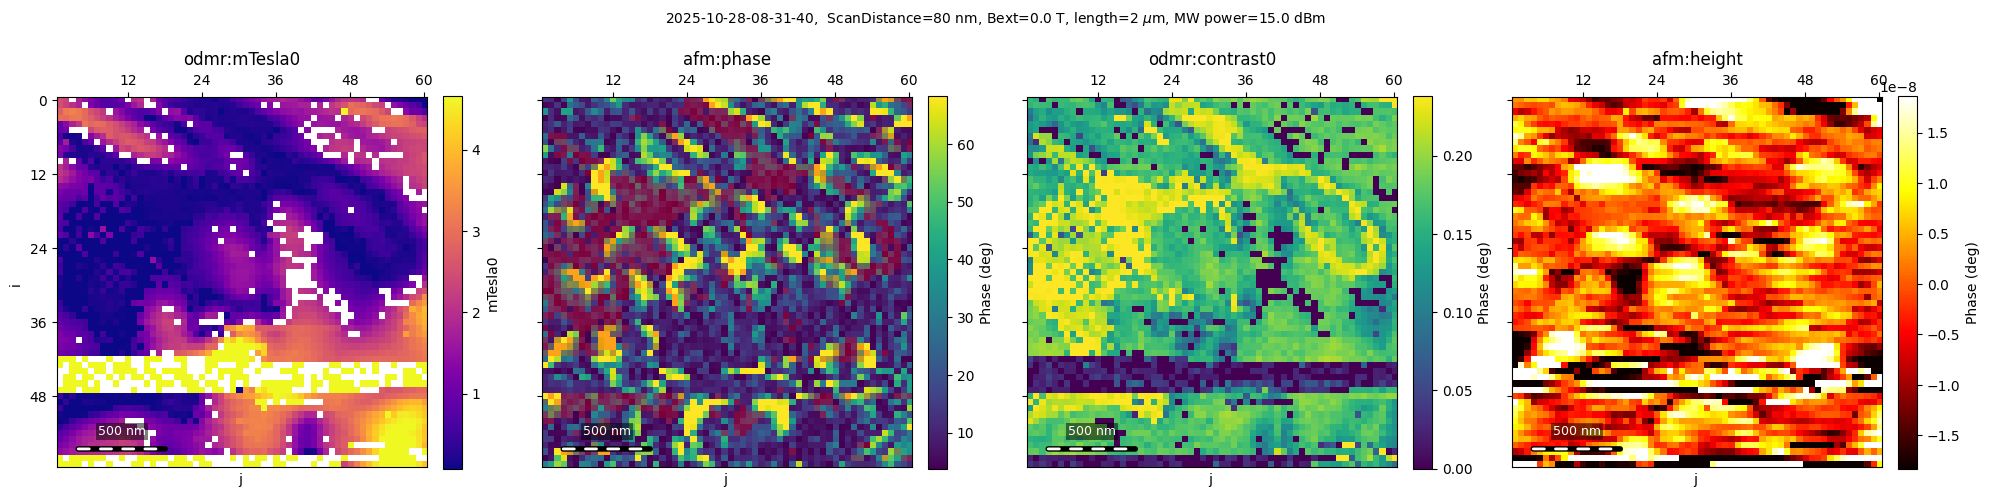

DATE: 2025-10-28-14-57-09


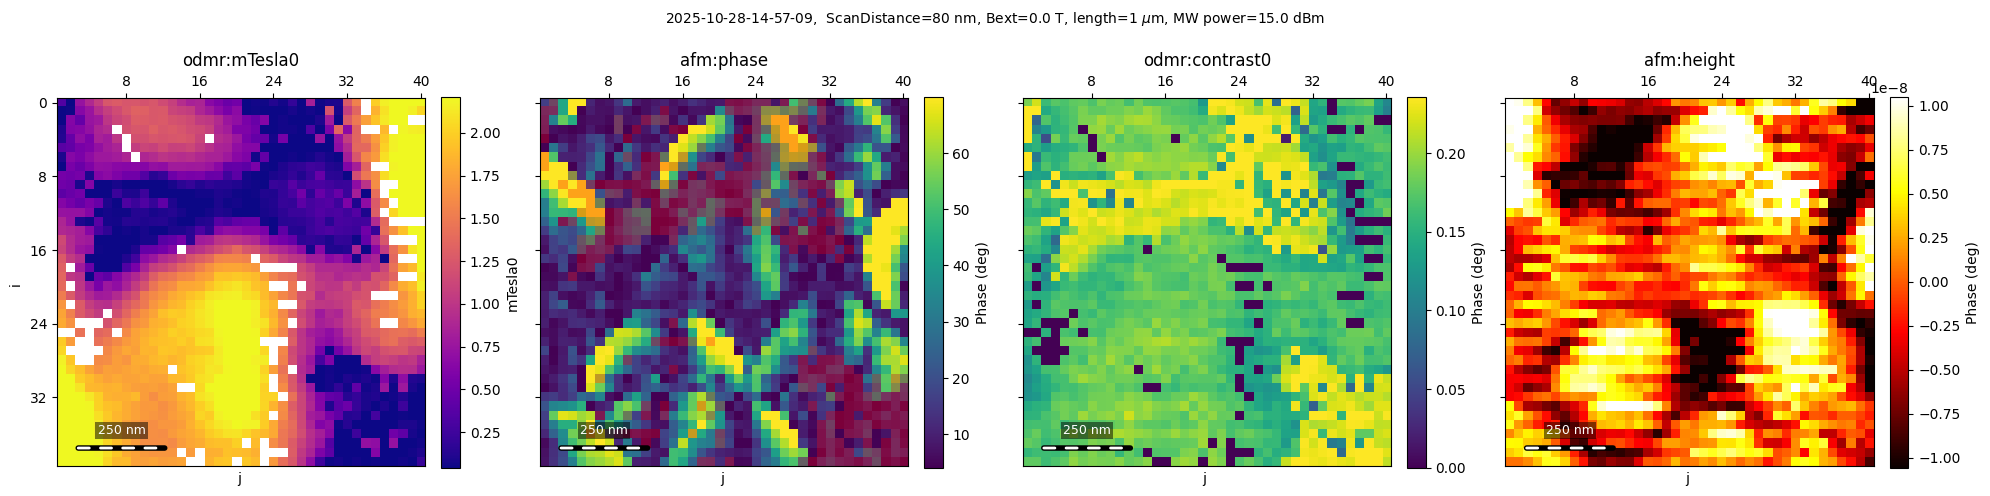

DATE: 2025-10-30-12-57-30


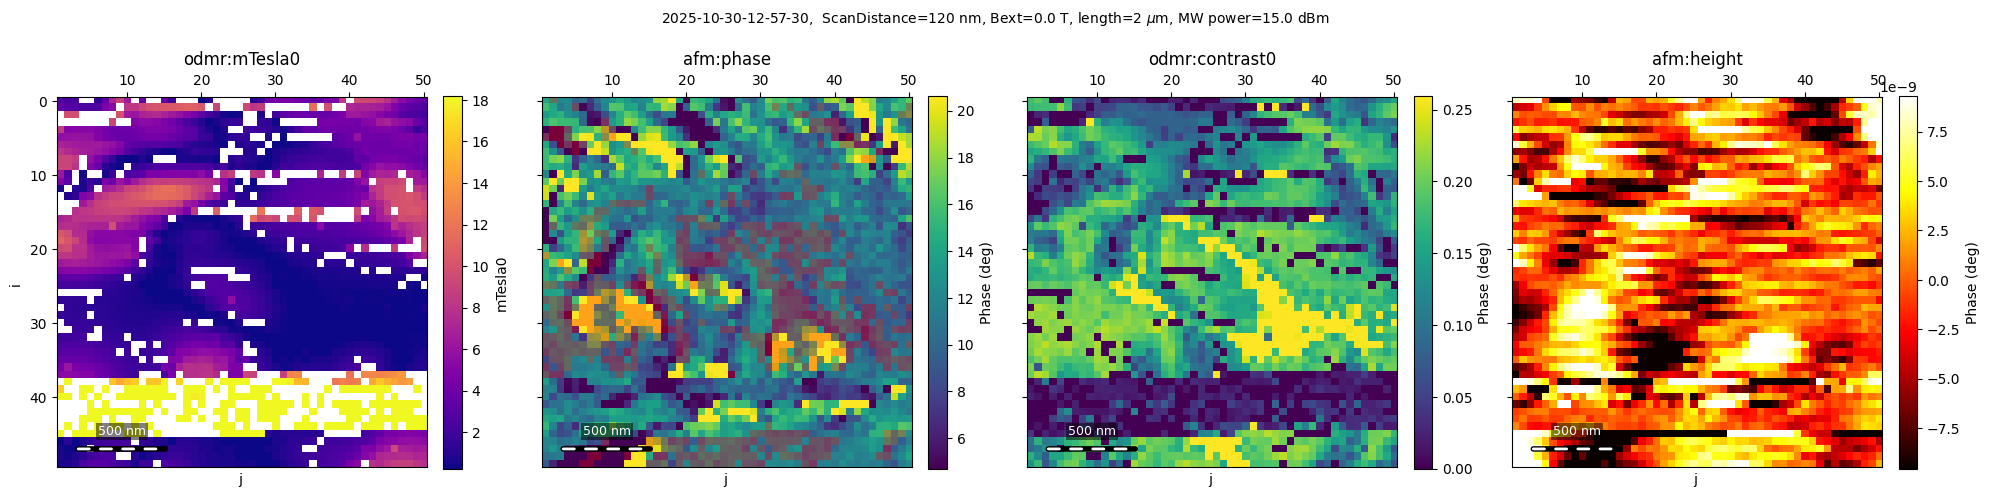

DATE: 2025-10-31-08-28-12


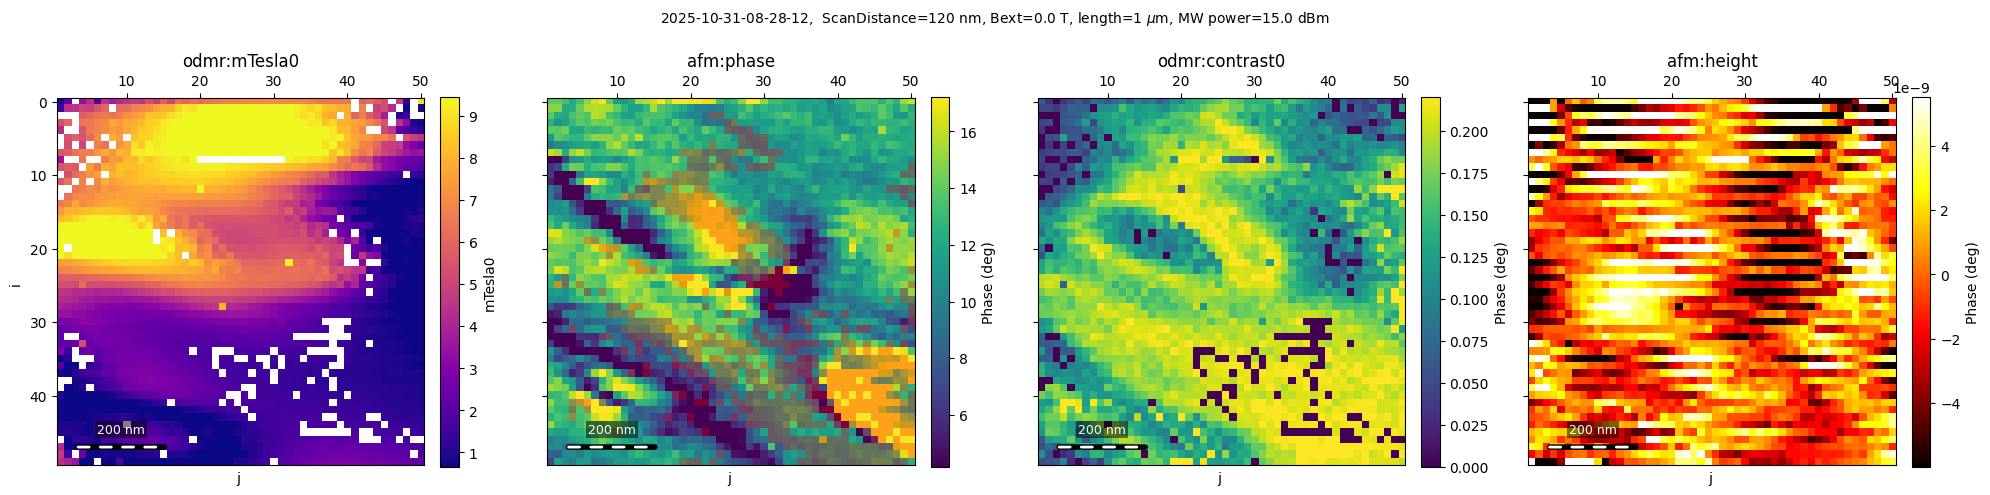

DATE: 2025-10-31-11-48-09


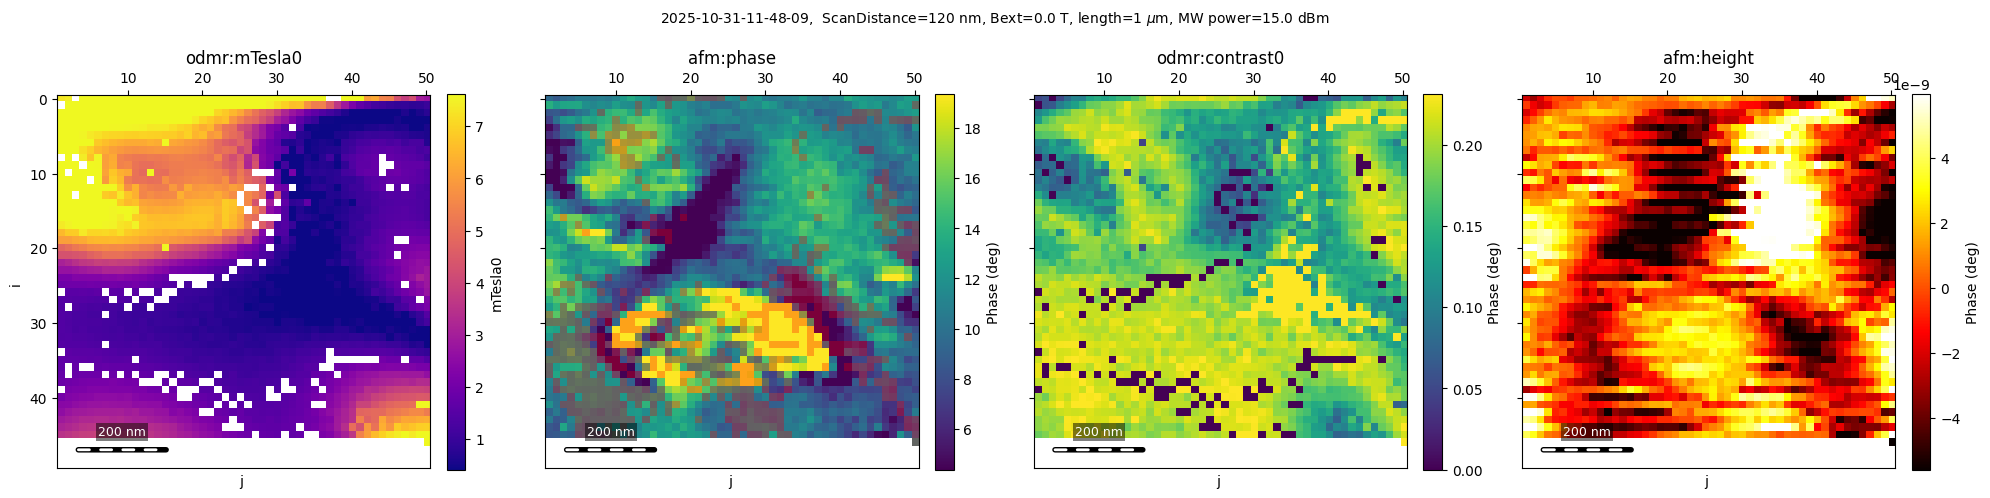

DATE: 2025-10-31-18-26-22


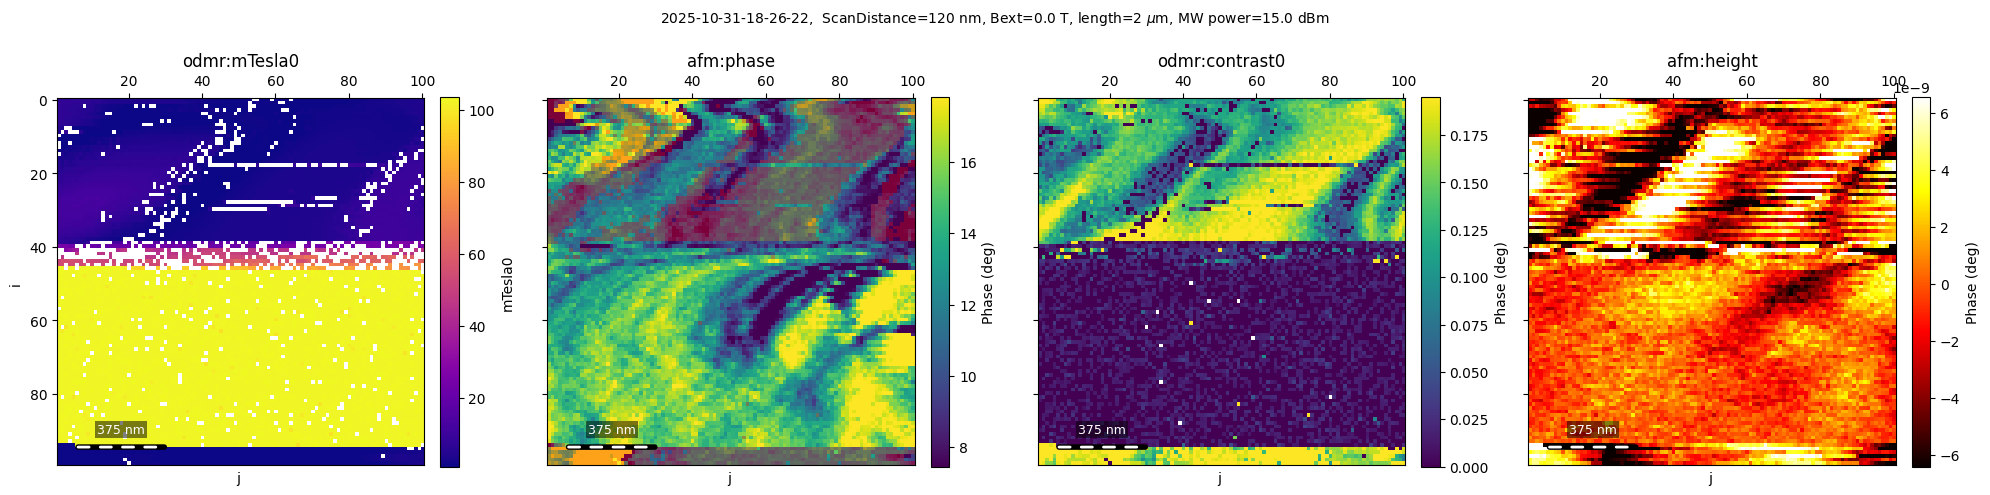

DATE: 2025-11-01-19-06-18


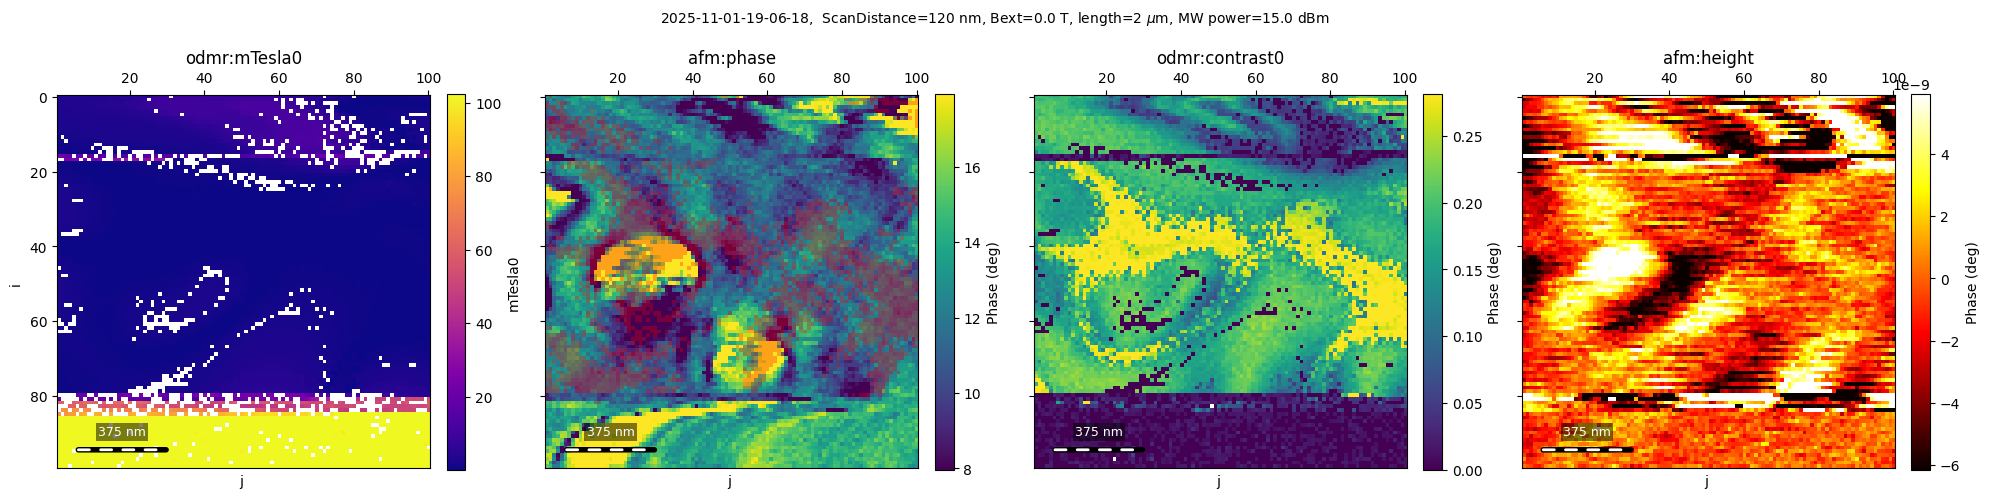

DATE: 2025-11-02-09-26-37


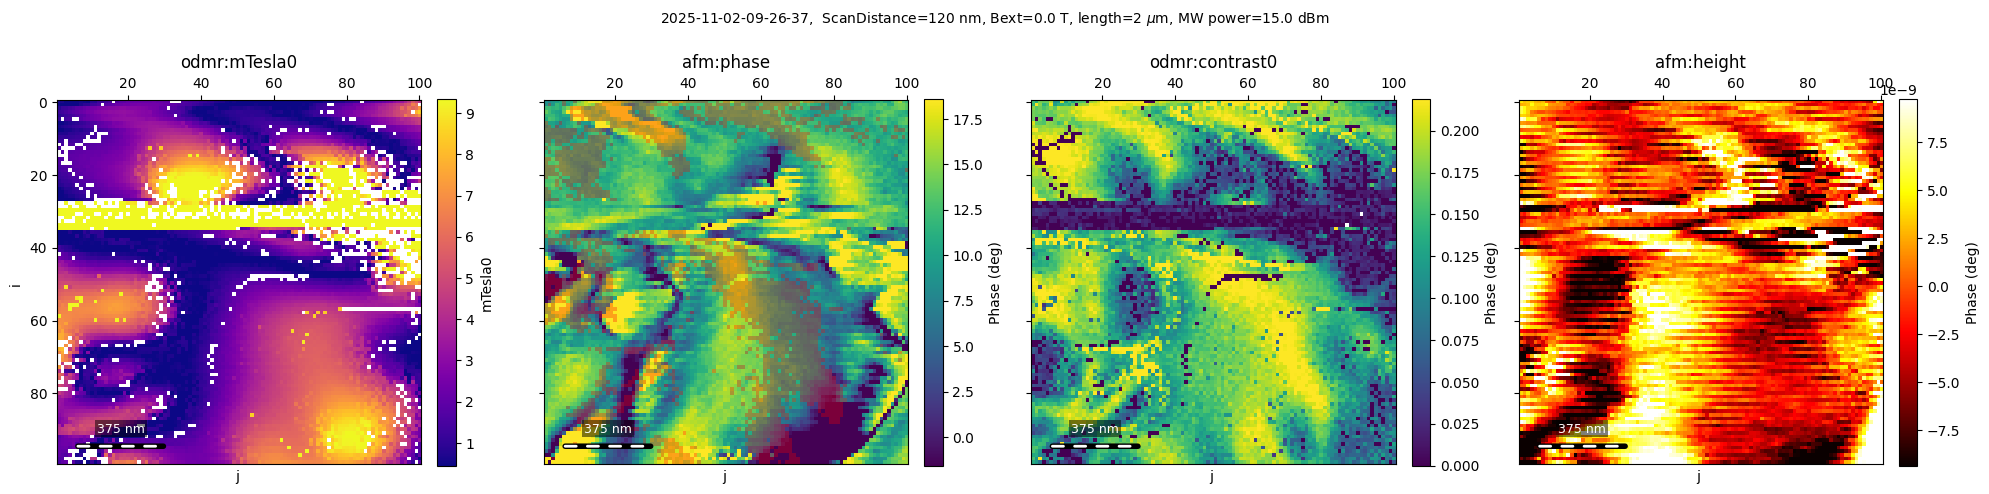

In [ ]:
import json
for date in dates:
    print(f"DATE: {date}")
    base_folder = data_directory / f"{date}-odmr_hardware"
    scalar_file = base_folder / "scalarData.txt"
    
    df2 = load_df2(scalar_file)

    meta_path = data_directory / f"{date}-odmr_hardware" / "imageMeta.json"
    with open(meta_path, "r") as f:
        meta = json.load(f)

    z_meas_physical = meta["scanHeightControl"]["scanDistance"]
    Bext=meta["vectorMagnetSettings"]["field_strength"]
    Size=meta["rect"]["size"][0]
    Size_um = Size * 1e6
    microwavepower=meta["microwavePower"]["Main Source"]
    #print(z_meas_physical)

    base3 = data_directory / f"{date}-odmr_hardware" / "seq0" / "eval" / "odmr.txt"         
    df3 = load_df1(base3, DOWNCAST_INT)
    
    preprocess="parabolic X"
    # Pour coller la bande que j'avais refais le 11-16
    if date == "2025-11-16-23-41-29":
        band_folder = data_directory / "2025-11-17-18-36-10-odmr_hardware"
        band_file = band_folder / "scalarData.txt"
        df_band = load_df2(band_file)
        df2 = concatener_data_df2(df2, df_band)
        preprocess="parabolic Y"
    elif date == "2025-11-15-20-13-45":
        preprocess="parabolic Y"
        
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 8))
    fig.suptitle(f"{date},  ScanDistance={z_meas_physical*1e9:.0f} nm, Bext={Bext:.1f} T, length={Size*1e6:.0f} $\mu$m, MW power={microwavepower} dBm", fontsize=10, y=0.82) #, fontweight='bold')

    im1 = plot_on_ax(df2, "odmr:mTesla0", ax1, robust_pct=8.5, cmap="plasma", Size_um=Size_um) # vmax=15 #scalebar=False
    if im1:
        cbar1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
        cbar1.set_label("mTesla0")
    im2 = plot_on_ax(df2, "afm:phase", ax2, robust_pct=5.5, Size_um=Size_um)
    if im2:
        cbar2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
        cbar2.set_label("Phase (deg)")
        ax2.set_ylabel("")
        ax2.set_yticklabels([])
    im3 = plot_on_ax(df2, "odmr:contrast0", ax3, robust_pct=5.5, Size_um=Size_um)
    if im3:
        cbar3 = fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
        cbar3.set_label("Phase (deg)")
        ax3.set_ylabel("")
        ax3.set_yticklabels([])
    im4 = plot_on_ax(df2, "afm:height", ax4, robust_pct=5.5, preprocess=preprocess, cmap="hot", Size_um=Size_um) #copper #hot
    if im4:
        cbar4 = fig.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)
        cbar4.set_label("Phase (deg)")
        ax4.set_ylabel("")
        ax4.set_yticklabels([])

    overlay_max_band(df2, "odmr:contrast0", ax2, top_pct=25.5, alpha=0.3)
    #overlay_max_band(df2, "odmr:contrast0", ax1, top_pct=29.5, alpha=0.4)
    #overlay_max_band(df2, "odmr:contrast0", ax4, top_pct=25.5, alpha=0.36, red=False, yellow=False, blue=True)

    plt.tight_layout()
    plt.show()

    #plot_QZabre(df3, NORMALIZE, SMOOTH_WIN,
    #          30,30, half=100, use_processed=True, grid=False, panel_size=(5.9,5.4),
    #          #pdf_path="map.pdf",
    #          )

# PREPROCESS :       
#       - None / "none"
#       - "mean plane subtract" / "mean_plane"
#       - "parabolic background subtract" / "parabolic"
#       - "linear X"
#       - "linear Y"
#       - "parabolic X"
#       - "parabolic Y"
